In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import wfdb
import neurokit2 as nk
import matplotlib.pyplot as plt
import re
import os

# Project root
PROJECT_ROOT = Path.cwd().parent

# If your notebook is already inside the project root, use:
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "mimic3"
ECG_DIR = DATA_DIR / "raw" / "mimic3_waveforms"

ECG_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Processed:", PROCESSED_DIR)
print("ECG:", ECG_DIR)

Project: /Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning
Processed: /Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/data/processed/mimic3
ECG: /Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/data/raw/mimic3_waveforms


In [25]:
clinical_path = (
    PROCESSED_DIR / "clinical_hourly_v1.csv"
)

hourly = pd.read_csv(clinical_path)

print("Clinical hourly dataset:", hourly.shape)

print("\nColumns:")
print(hourly.columns.tolist())

print("\nPatients:")
print(hourly["subject_id"].nunique())

print("\nICU stays:")
print(hourly["icustay_id"].nunique())

display(hourly.head())

Clinical hourly dataset: (4556, 17)

Columns:
['subject_id', 'hadm_id', 'icustay_id', 'hour', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'heart_rate', 'map', 'resp_rate', 'spo2', 'gcs_total', 'previous_gcs', 'gcs_change', 'gcs_last_observed', 'previous_observed_gcs', 'sae']

Patients:
25

ICU stays:
38


,subject_id,hadm_id,icustay_id,hour,gcs_eye,gcs_motor,gcs_verbal,heart_rate,map,resp_rate,spo2,gcs_total,previous_gcs,gcs_change,gcs_last_observed,previous_observed_gcs,sae
0,10076,198503,201006,0,NaN,NaN,NaN,100.0,NaN,32.0,93.0,NaN,NaN,NaN,NaN,NaN,0
1,10076,198503,201006,1,NaN,NaN,NaN,104.5,NaN,33.5,94.0,NaN,NaN,NaN,NaN,NaN,0
2,10076,198503,201006,2,NaN,NaN,NaN,104.5,NaN,32.5,99.5,NaN,NaN,NaN,NaN,NaN,0
3,10076,198503,201006,3,4.0,6.0,5.0,103.0,NaN,36.0,99.0,15.0,NaN,NaN,15.0,NaN,0
4,10076,198503,201006,4,NaN,NaN,NaN,90.0,NaN,32.0,99.0,NaN,15.0,NaN,15.0,15.0,0


In [26]:
sepsis_subjects = sorted(
    hourly["subject_id"]
    .dropna()
    .astype(int)
    .unique()
)

print("Number of patients:", len(sepsis_subjects))

print("\nSubject IDs:")
print(sepsis_subjects)

Number of patients: 25

Subject IDs:
[np.int64(10006), np.int64(10013), np.int64(10019), np.int64(10029), np.int64(10036), np.int64(10038), np.int64(10045), np.int64(10056), np.int64(10059), np.int64(10061), np.int64(10076), np.int64(10088), np.int64(10094), np.int64(10124), np.int64(10130), np.int64(10132), np.int64(40177), np.int64(40612), np.int64(40655), np.int64(41914), np.int64(41976), np.int64(42135), np.int64(44154), np.int64(44212), np.int64(44228)]


In [27]:
import urllib.request

records_url = (
    "https://physionet.org/files/"
    "mimic3wdb-matched/1.0/RECORDS-waveforms"
)

records_file = ECG_DIR / "RECORDS-waveforms"

if not records_file.exists():

    urllib.request.urlretrieve(
        records_url,
        records_file
    )

print("Downloaded:", records_file)
print("Size:", records_file.stat().st_size / 1024, "KB")

Downloaded: /Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/data/raw/mimic3_waveforms/RECORDS-waveforms
Size: 806.3759765625 KB


In [28]:
records = pd.read_csv(
    records_file,
    header=None,
    names=["record"]
)

print("Total waveform records:", len(records))

display(records.head(20))

Total waveform records: 22317


,record
0,p00/p000020/p000020-2183-04-28-17-47
1,p00/p000030/p000030-2172-10-16-12-22
2,p00/p000033/p000033-2116-12-24-12-35
3,p00/p000033/p000033-2116-12-25-13-11
4,p00/p000052/p000052-2191-01-10-02-21
5,p00/p000052/p000052-2191-01-10-12-15
6,p00/p000079/p000079-2175-09-26-01-25
7,p00/p000079/p000079-2175-09-26-12-28
8,p00/p000085/p000085-2167-07-25-21-11
9,p00/p000107/p000107-2121-11-30-20-03


In [29]:
def extract_subject_id(record_name):

    match = re.search(
        r"/p(\d{6})/",
        "/" + record_name
    )

    if match:
        return int(match.group(1))

    return None


records["subject_id"] = records["record"].apply(
    extract_subject_id
)

matched_records = records[
    records["subject_id"].isin(sepsis_subjects)
].copy()

print(
    "Waveform records for our patients:",
    len(matched_records)
)

print(
    "Patients with waveform records:",
    matched_records["subject_id"].nunique()
)

print(
    "Patients WITHOUT waveform records:",
    len(
        set(sepsis_subjects)
        - set(matched_records["subject_id"])
    )
)

display(matched_records.head(30))

Waveform records for our patients: 13
Patients with waveform records: 5
Patients WITHOUT waveform records: 20


,record,subject_id
2452,p01/p010013/p010013-2125-10-04-23-37,10013
2458,p01/p010045/p010045-2129-11-24-22-48,10045
2459,p01/p010045/p010045-2129-11-24-23-32,10045
2461,p01/p010061/p010061-2107-01-20-12-33,10061
2462,p01/p010061/p010061-2107-02-03-14-02,10061
2471,p01/p010124/p010124-2192-04-24-02-25,10124
8288,p04/p041976/p041976-2201-09-28-18-43,41976
8289,p04/p041976/p041976-2201-09-30-16-25,41976
8290,p04/p041976/p041976-2201-12-31-23-27,41976
8291,p04/p041976/p041976-2202-05-01-23-27,41976


In [30]:
def get_header_url(record):

    return (
        "https://physionet.org/files/"
        "mimic3wdb-matched/1.0/"
        + record
        + ".hea"
    )


# Test first 10 records
test_records = matched_records.head(10)

header_results = []

for _, row in test_records.iterrows():

    record = row["record"]

    url = get_header_url(record)

    try:

        with urllib.request.urlopen(url) as response:
            text = response.read().decode("utf-8")

        header_results.append({
            "subject_id": row["subject_id"],
            "record": record,
            "header": text
        })

    except Exception as e:

        header_results.append({
            "subject_id": row["subject_id"],
            "record": record,
            "header": f"ERROR: {e}"
        })

headers_df = pd.DataFrame(header_results)

print("Headers inspected:", len(headers_df))

display(headers_df[["subject_id", "record"]])

Headers inspected: 10


,subject_id,record
0,10013,p01/p010013/p010013-2125-10-04-23-37
1,10045,p01/p010045/p010045-2129-11-24-22-48
2,10045,p01/p010045/p010045-2129-11-24-23-32
3,10061,p01/p010061/p010061-2107-01-20-12-33
4,10061,p01/p010061/p010061-2107-02-03-14-02
5,10124,p01/p010124/p010124-2192-04-24-02-25
6,41976,p04/p041976/p041976-2201-09-28-18-43
7,41976,p04/p041976/p041976-2201-09-30-16-25
8,41976,p04/p041976/p041976-2201-12-31-23-27
9,41976,p04/p041976/p041976-2202-05-01-23-27


In [31]:
def find_ecg_signals(header_text):

    lines = header_text.splitlines()

    signals = []

    for line in lines[1:]:

        parts = line.split()

        if len(parts) < 2:
            continue

        signal_name = parts[8] if len(parts) > 8 else ""

        if re.search(
            r"ECG|II|III|I|V\d|AVR|AVL|AVF",
            signal_name,
            re.IGNORECASE
        ):
            signals.append(signal_name)

    return signals


headers_df["ecg_signals"] = headers_df["header"].apply(
    find_ecg_signals
)

display(
    headers_df[
        [
            "subject_id",
            "record",
            "ecg_signals"
        ]
    ]
)

,subject_id,record,ecg_signals
0,10013,p01/p010013/p010013-2125-10-04-23-37,[]
1,10045,p01/p010045/p010045-2129-11-24-22-48,[]
2,10045,p01/p010045/p010045-2129-11-24-23-32,[]
3,10061,p01/p010061/p010061-2107-01-20-12-33,[]
4,10061,p01/p010061/p010061-2107-02-03-14-02,[]
5,10124,p01/p010124/p010124-2192-04-24-02-25,[]
6,41976,p04/p041976/p041976-2201-09-28-18-43,[]
7,41976,p04/p041976/p041976-2201-09-30-16-25,[]
8,41976,p04/p041976/p041976-2201-12-31-23-27,[]
9,41976,p04/p041976/p041976-2202-05-01-23-27,[]


In [32]:
if len(matched_records) > 0:

    test_record = matched_records.iloc[0]["record"]

    print("Testing record:")
    print(test_record)

    url = (
        "https://physionet.org/files/"
        "mimic3wdb-matched/1.0/"
        + test_record
    )

    print("\nRecord URL:")
    print(url)

Testing record:
p01/p010013/p010013-2125-10-04-23-37

Record URL:
https://physionet.org/files/mimic3wdb-matched/1.0/p01/p010013/p010013-2125-10-04-23-37


In [33]:
if len(matched_records) > 0:

    test_record = matched_records.iloc[0]["record"]

    print("Reading:", test_record)

    try:

        record = wfdb.rdrecord(
            "https://physionet.org/files/"
            "mimic3wdb-matched/1.0/"
            + test_record
        )

        print("SUCCESS")

        print("\nSampling frequency:")
        print(record.fs)

        print("\nNumber of signals:")
        print(record.n_sig)

        print("\nSignal names:")
        print(record.sig_name)

        print("\nSamples:")
        print(record.p_signal.shape)

    except Exception as e:

        print("ERROR:")
        print(e)

Reading: p01/p010013/p010013-2125-10-04-23-37
ERROR:
[Errno 2] No such file or directory: '/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/notebooks/https:/physionet.org/files/mimic3wdb-matched/1.0/p01/p010013/p010013-2125-10-04-23-37.hea'


In [34]:
# ============================================================
# SELECT ONE MATCHED WAVEFORM
# ============================================================

print("Available matched records:")
display(
    matched_records[
        ["subject_id", "record"]
    ].head(20)
)

test_record = matched_records.iloc[0]["record"]

print("\nSelected record:")
print(test_record)

Available matched records:


,subject_id,record
2452,10013,p01/p010013/p010013-2125-10-04-23-37
2458,10045,p01/p010045/p010045-2129-11-24-22-48
2459,10045,p01/p010045/p010045-2129-11-24-23-32
2461,10061,p01/p010061/p010061-2107-01-20-12-33
2462,10061,p01/p010061/p010061-2107-02-03-14-02
2471,10124,p01/p010124/p010124-2192-04-24-02-25
8288,41976,p04/p041976/p041976-2201-09-28-18-43
8289,41976,p04/p041976/p041976-2201-09-30-16-25
8290,41976,p04/p041976/p041976-2201-12-31-23-27
8291,41976,p04/p041976/p041976-2202-05-01-23-27



Selected record:
p01/p010013/p010013-2125-10-04-23-37


In [36]:
# ============================================================
# RESET WAVEFORM TEST
# ============================================================

test_record_name = matched_records.iloc[0]["record"]

print("Test record:")
print(test_record_name)

print("\nSubject:")
print(matched_records.iloc[0]["subject_id"])

Test record:
p01/p010013/p010013-2125-10-04-23-37

Subject:
10013


In [38]:
import requests

test_record = "p010013-2125-10-04-23-37"

subject = test_record.split("-")[0]

folder = subject[:3]

header_url = (
    "https://physionet.org/files/"
    "mimic3wdb-matched/1.0/"
    f"{folder}/{subject}/{test_record}.hea"
)

print("Header URL:")
print(header_url)

response = requests.get(header_url)

print("\nHTTP status:", response.status_code)
print("\nFirst 1000 characters:\n")
print(response.text[:1000])

Header URL:
https://physionet.org/files/mimic3wdb-matched/1.0/p01/p010013/p010013-2125-10-04-23-37.hea

HTTP status: 200

First 1000 characters:

p010013-2125-10-04-23-37/15 3 125 28531270 23:37:18.298 04/10/2125
3609176_layout 0
~ 1019
3609176_0001 48703
3609176_0002 384
3609176_0003 85913
3609176_0004 1643
3609176_0005 4612
3609176_0006 1245
3609176_0007 2595
3609176_0008 4722405
3609176_0009 5750
3609176_0010 3519250
~ 251
3609176_0011 12240000
3609176_0012 7897500



In [39]:
import wfdb

record_obj = wfdb.rdheader(
    test_record,
    pn_dir="mimic3wdb-matched/1.0/p01/p010013"
)

print("HEADER LOADED SUCCESSFULLY")

print("\nRecord name:")
print(record_obj.record_name)

print("\nSampling frequency:")
print(record_obj.fs)

print("\nNumber of signals:")
print(record_obj.n_sig)

print("\nSignal names:")
print(record_obj.sig_name)

print("\nSignal length:")
print(record_obj.sig_len)

HEADER LOADED SUCCESSFULLY

Record name:
p010013-2125-10-04-23-37

Sampling frequency:
125

Number of signals:
3

Signal names:
None

Signal length:
28531270


In [40]:
# ============================================================
# INSPECT EXACT WAVEFORM HEADER
# ============================================================

import requests

test_record = "p010013-2125-10-04-23-37"

subject = test_record.split("-")[0]
folder = subject[:3]

header_url = (
    "https://physionet.org/files/"
    "mimic3wdb-matched/1.0/"
    f"{folder}/{subject}/{test_record}.hea"
)

response = requests.get(header_url)

print("HTTP:", response.status_code)
print("=" * 80)
print(response.text)
print("=" * 80)

HTTP: 200
p010013-2125-10-04-23-37/15 3 125 28531270 23:37:18.298 04/10/2125
3609176_layout 0
~ 1019
3609176_0001 48703
3609176_0002 384
3609176_0003 85913
3609176_0004 1643
3609176_0005 4612
3609176_0006 1245
3609176_0007 2595
3609176_0008 4722405
3609176_0009 5750
3609176_0010 3519250
~ 251
3609176_0011 12240000
3609176_0012 7897500



In [42]:
# ============================================================
# INSPECT MULTIRECORD HEADER
# ============================================================

print("Object type:", type(record_obj))

print("\nRecord name:")
print(record_obj.record_name)

print("\nSampling frequency:")
print(record_obj.fs)

print("\nNumber of signals:")
print(record_obj.n_sig)

print("\nSignal length:")
print(record_obj.sig_len)

print("\nSignal names:")
print(record_obj.sig_name)

print("\nNumber of segments:")
print(len(record_obj.segments))

print("\nSegments:")
for i, segment in enumerate(record_obj.segments):
    print(
        i,
        type(segment),
        getattr(segment, "record_name", None),
        getattr(segment, "n_sig", None),
        getattr(segment, "sig_len", None),
        getattr(segment, "sig_name", None)
    )

Object type: <class 'wfdb.io.record.MultiRecord'>

Record name:
p010013-2125-10-04-23-37

Sampling frequency:
125

Number of signals:
3

Signal length:
28531270

Signal names:
None

Number of segments:


TypeError: object of type 'NoneType' has no len()

In [44]:
# ============================================================
# READ THE RAW HEADER DIRECTLY
# ============================================================

import requests

test_record = "p010013-2125-10-04-23-37"

subject = test_record.split("-")[0]
folder = subject[:3]

header_url = (
    "https://physionet.org/files/"
    "mimic3wdb-matched/1.0/"
    f"{folder}/{subject}/{test_record}.hea"
)

response = requests.get(header_url)

print("HTTP status:", response.status_code)

header_text = response.text

print("\nHEADER:")
print("=" * 100)
print(header_text)
print("=" * 100)

HTTP status: 200

HEADER:
p010013-2125-10-04-23-37/15 3 125 28531270 23:37:18.298 04/10/2125
3609176_layout 0
~ 1019
3609176_0001 48703
3609176_0002 384
3609176_0003 85913
3609176_0004 1643
3609176_0005 4612
3609176_0006 1245
3609176_0007 2595
3609176_0008 4722405
3609176_0009 5750
3609176_0010 3519250
~ 251
3609176_0011 12240000
3609176_0012 7897500



In [45]:
# ============================================================
# INSPECT THE LAYOUT HEADER
# ============================================================

layout_record = "3609176_layout"

layout_url = (
    "https://physionet.org/files/"
    "mimic3wdb-matched/1.0/"
    f"{folder}/{subject}/{layout_record}.hea"
)

response = requests.get(layout_url)

print("HTTP status:", response.status_code)

print("\nLAYOUT HEADER:")
print("=" * 100)
print(response.text)
print("=" * 100)

HTTP status: 200

LAYOUT HEADER:
3609176_layout 3 125 0 23:37:18.298
~ 0 40/mV 10 0 -512 0 0 II
~ 0 1.25(-91)/mmHg 9 0 -256 0 0 ABP
~ 0 5/mmHg 11 0 -1024 0 0 PAP



In [47]:
# ============================================================
# READ THE VERIFIED ECG SEGMENT
# ============================================================

import wfdb

segment_name = "3609176_0001"

segment = wfdb.rdrecord(
    segment_name,
    pn_dir="mimic3wdb-matched/1.0/p01/p010013",
    physical=True
)

print("SUCCESS")
print("Record:", segment.record_name)
print("Sampling frequency:", segment.fs)
print("Number of signals:", segment.n_sig)
print("Signal names:", segment.sig_name)
print("Signal shape:", segment.p_signal.shape)

SUCCESS
Record: 3609176_0001
Sampling frequency: 125
Number of signals: 1
Signal names: ['II']
Signal shape: (48703, 1)


In [48]:
# ============================================================
# VERIFY ECG WAVEFORM — LEAD II
# ============================================================

ecg = segment.p_signal[:, 0]

fs = int(segment.fs)

print("ECG samples:", len(ecg))
print("Sampling frequency:", fs)
print("Duration (seconds):", len(ecg) / fs)

print("\nECG statistics:")
print("Minimum:", np.nanmin(ecg))
print("Maximum:", np.nanmax(ecg))
print("Mean:", np.nanmean(ecg))
print("Std:", np.nanstd(ecg))

ECG samples: 48703
Sampling frequency: 125
Duration (seconds): 389.624

ECG statistics:
Minimum: -3.0
Maximum: 1.575
Mean: -0.0013144382830149928
Std: 0.08381908653650717


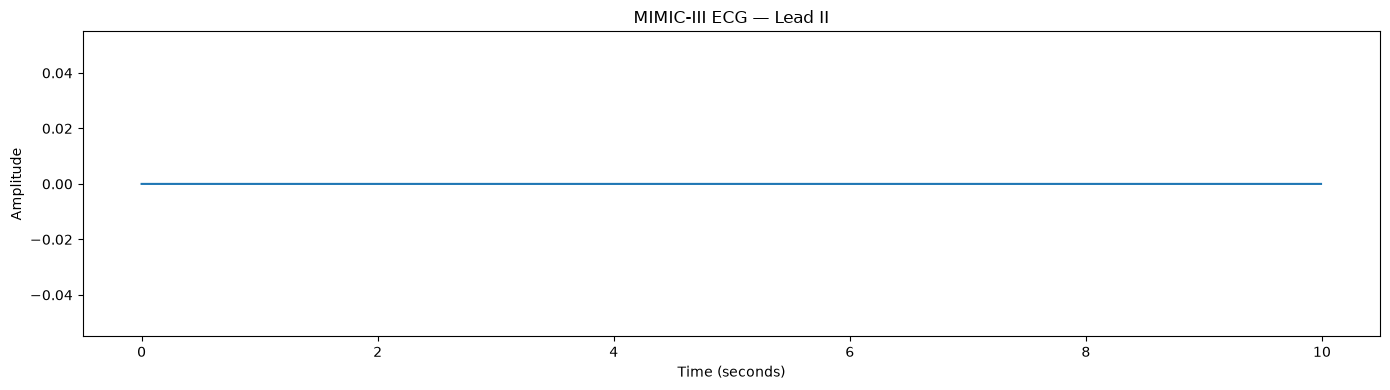

In [49]:
# ============================================================
# PLOT FIRST 10 SECONDS
# ============================================================

seconds = 10
n_samples = seconds * fs

time = np.arange(n_samples) / fs

plt.figure(figsize=(14, 4))

plt.plot(
    time,
    ecg[:n_samples]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIMIC-III ECG — Lead II")

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# FIND WHERE THE ECG SIGNAL IS ACTUALLY NON-ZERO
# ============================================================

ecg = segment.p_signal[:, 0]

print("Total samples:", len(ecg))

# Check different portions of the signal
window_seconds = 10
window_samples = window_seconds * fs

for start_sec in [0, 10, 30, 60, 120, 180, 240, 300]:

    start = int(start_sec * fs)
    end = min(start + window_samples, len(ecg))

    chunk = ecg[start:end]

    print(
        f"{start_sec:>3}–{start_sec+10:>3} sec | "
        f"min={np.nanmin(chunk):.4f} | "
        f"max={np.nanmax(chunk):.4f} | "
        f"std={np.nanstd(chunk):.4f}"
    )

Total samples: 48703
  0– 10 sec | min=0.0000 | max=0.0000 | std=0.0000
 10– 20 sec | min=0.0000 | max=0.0000 | std=0.0000
 30– 40 sec | min=0.0000 | max=0.0000 | std=0.0000
 60– 70 sec | min=0.0000 | max=0.0000 | std=0.0000
120–130 sec | min=0.0000 | max=0.0000 | std=0.0000
180–190 sec | min=0.0000 | max=0.0000 | std=0.0000
240–250 sec | min=0.0000 | max=0.0000 | std=0.0000
300–310 sec | min=0.0000 | max=0.0000 | std=0.0000


In [51]:
# ============================================================
# FIND FIRST REGION WITH MEANINGFUL ECG ACTIVITY
# ============================================================

threshold = 0.005

activity = []

window = int(2 * fs)   # 2-second windows

for start in range(0, len(ecg), window):

    end = min(start + window, len(ecg))

    chunk = ecg[start:end]

    std = np.nanstd(chunk)

    activity.append(
        (start / fs, end / fs, std)
    )

active_windows = [
    x for x in activity
    if x[2] > threshold
]

print("First active windows:")
print(active_windows[:10])

First active windows:
[(384.0, 386.0, np.float64(0.9907339218985224)), (386.0, 388.0, np.float64(0.32616101851692825)), (388.0, 389.624, np.float64(0.04980944786245321))]


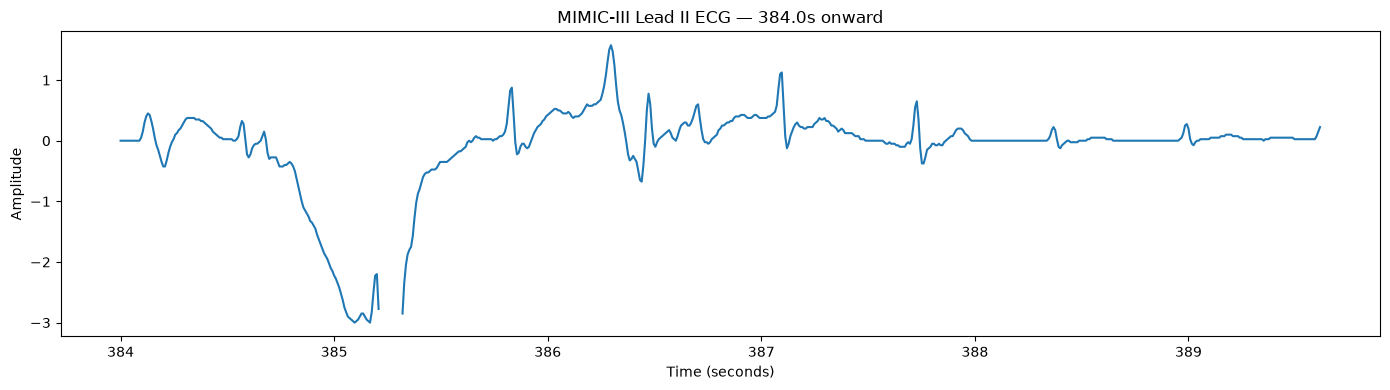

In [52]:
# ============================================================
# PLOT FIRST ACTIVE ECG WINDOW
# ============================================================

start_sec = active_windows[0][0]

start = int(start_sec * fs)
end = min(start + 10 * fs, len(ecg))

time = np.arange(start, end) / fs

plt.figure(figsize=(14, 4))

plt.plot(
    time,
    ecg[start:end]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    f"MIMIC-III Lead II ECG — {start_sec:.1f}s onward"
)

plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# SIMPLE R-PEAK DETECTION — NO ECG_PROCESS
# ============================================================

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

# Use the actual active portion of this segment
start_sec = 384
end_sec = 389.5

start = int(start_sec * fs)
end = min(int(end_sec * fs), len(ecg))

ecg_test = ecg[start:end]

print("Samples:", len(ecg_test))
print("Duration:", len(ecg_test) / fs, "seconds")

# Clean ECG only
ecg_clean = nk.ecg_clean(
    ecg_test,
    sampling_rate=fs
)

# Detect R-peaks
_, info = nk.ecg_peaks(
    ecg_clean,
    sampling_rate=fs
)

rpeaks = info["ECG_R_Peaks"]

print("\nR-peaks detected:", len(rpeaks))
print("Peak sample positions:", rpeaks)
print("Peak times:", rpeaks / fs + start_sec)

Samples: 687
Duration: 5.496 seconds

R-peaks detected: 8
Peak sample positions: [ 71 149 228 287 386 466 546 624]
Peak times: [384.568 385.192 385.824 386.296 387.088 387.728 388.368 388.992]


/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/.venv/lib/python3.11/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 13 missing data points in your signal. Filling missing values using `signal_fillmissing`.
  warn(


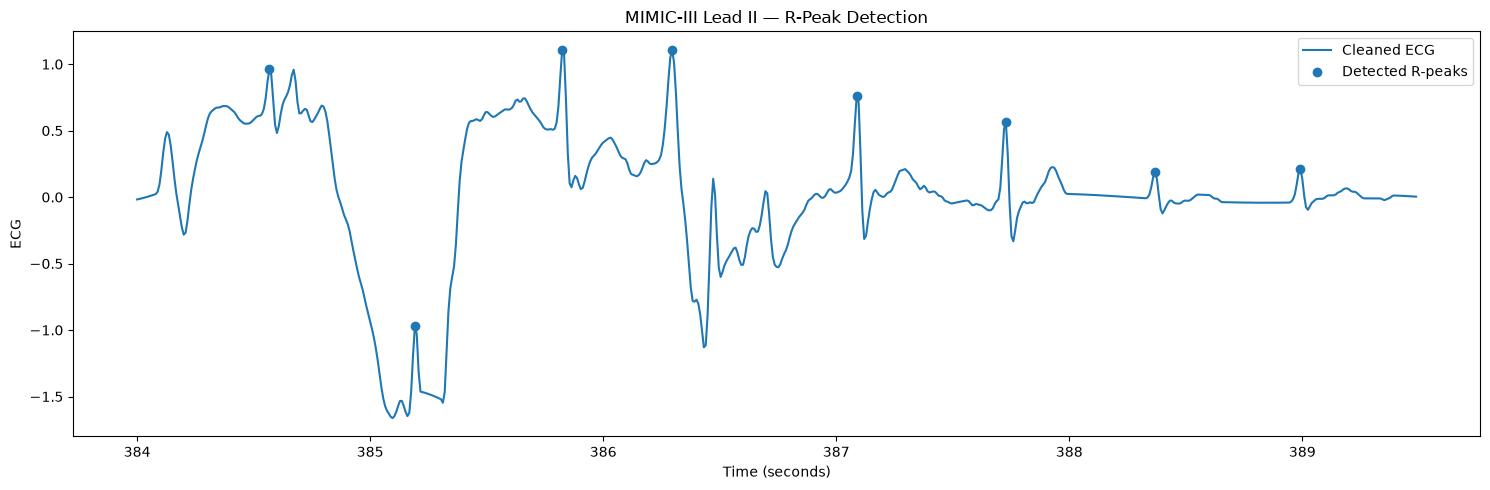

In [56]:
# ============================================================
# VISUALIZE R-PEAKS
# ============================================================

time = np.arange(len(ecg_test)) / fs + start_sec

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_clean,
    label="Cleaned ECG"
)

plt.scatter(
    rpeaks / fs + start_sec,
    ecg_clean[rpeaks],
    marker="o",
    label="Detected R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title("MIMIC-III Lead II — R-Peak Detection")

plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# CHECK ALL SEGMENTS FOR ECG LENGTH / AVAILABILITY
# ============================================================

segment_names = [
    "3609176_0001",
    "3609176_0002",
    "3609176_0003",
    "3609176_0004",
    "3609176_0005",
    "3609176_0006",
    "3609176_0007",
    "3609176_0008",
    "3609176_0009",
    "3609176_0010",
    "3609176_0011",
    "3609176_0012",
]

segment_info = []

for name in segment_names:

    try:

        hdr = wfdb.rdheader(
            name,
            pn_dir="mimic3wdb-matched/1.0/p01/p010013"
        )

        segment_info.append({
            "segment": name,
            "fs": hdr.fs,
            "n_sig": hdr.n_sig,
            "sig_len": hdr.sig_len,
            "duration_sec": (
                hdr.sig_len / hdr.fs
                if hdr.sig_len is not None
                else None
            )
        })

    except Exception as e:

        segment_info.append({
            "segment": name,
            "fs": None,
            "n_sig": None,
            "sig_len": None,
            "duration_sec": None,
            "error": str(e)
        })

segments_df = pd.DataFrame(segment_info)

display(segments_df)

,segment,fs,n_sig,sig_len,duration_sec
0,3609176_0001,125,1,48703,389.624
1,3609176_0002,125,1,384,3.072
2,3609176_0003,125,1,85913,687.304
3,3609176_0004,125,3,1643,13.144
4,3609176_0005,125,3,4612,36.896
5,3609176_0006,125,3,1245,9.960
6,3609176_0007,125,2,2595,20.760
7,3609176_0008,125,2,4722405,37779.240
8,3609176_0009,125,3,5750,46.000
9,3609176_0010,125,3,3519250,28154.000


In [58]:
# ============================================================
# LOAD LONG ECG SEGMENT
# ============================================================

segment_name = "3609176_0003"

ecg_record = wfdb.rdrecord(
    segment_name,
    pn_dir="mimic3wdb-matched/1.0/p01/p010013",
    physical=True
)

print("SUCCESS")
print("Record:", segment_name)
print("Sampling frequency:", ecg_record.fs)
print("Number of signals:", ecg_record.n_sig)
print("Signal names:", ecg_record.sig_name)
print("Signal shape:", ecg_record.p_signal.shape)
print("Duration (seconds):", ecg_record.sig_len / ecg_record.fs)

SUCCESS
Record: 3609176_0003
Sampling frequency: 125
Number of signals: 1
Signal names: ['II']
Signal shape: (85913, 1)
Duration (seconds): 687.304


ECG samples: 85913
Sampling frequency: 125
Duration: 687.304 seconds

R-peaks detected: 1083
First 20 R-peak positions:
[  88  168  246  324  404  483  561  640  719  796  874  953 1032 1109
 1188 1268 1345 1423 1503 1581]

First 20 R-peak times:
[ 0.704  1.344  1.968  2.592  3.232  3.864  4.488  5.12   5.752  6.368
  6.992  7.624  8.256  8.872  9.504 10.144 10.76  11.384 12.024 12.648]


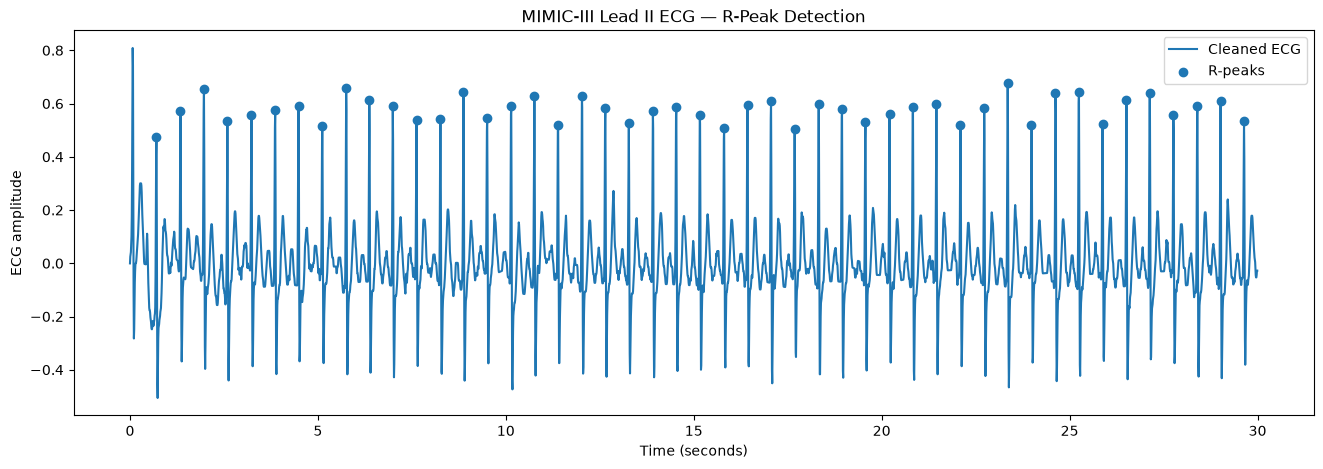

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Get ECG signal
ecg = ecg_record.p_signal[:, 0]
fs = ecg_record.fs

print("ECG samples:", len(ecg))
print("Sampling frequency:", fs)
print("Duration:", len(ecg) / fs, "seconds")

# Clean ECG
ecg_clean = nk.ecg_clean(
    ecg,
    sampling_rate=fs
)

# Detect R-peaks
_, rpeaks = nk.ecg_peaks(
    ecg_clean,
    sampling_rate=fs
)

r_peak_indices = rpeaks["ECG_R_Peaks"]

print("\nR-peaks detected:", len(r_peak_indices))
print("First 20 R-peak positions:")
print(r_peak_indices[:20])

# Convert to seconds
r_peak_times = r_peak_indices / fs

print("\nFirst 20 R-peak times:")
print(r_peak_times[:20])

# Plot first 30 seconds
plot_end = int(30 * fs)

plt.figure(figsize=(16, 5))

plt.plot(
    np.arange(plot_end) / fs,
    ecg_clean[:plot_end],
    label="Cleaned ECG"
)

peaks_in_window = r_peak_indices[r_peak_indices < plot_end]

plt.scatter(
    peaks_in_window / fs,
    ecg_clean[peaks_in_window],
    label="R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("MIMIC-III Lead II ECG — R-Peak Detection")
plt.legend()
plt.show()

In [60]:
# ============================================================
# RR INTERVAL VALIDATION
# ============================================================

# R-peak locations already obtained
r_peak_indices = r_peak_indices

# RR intervals in seconds
rr_intervals = np.diff(r_peak_indices) / fs

# Instantaneous heart rate
heart_rates = 60 / rr_intervals

print("Number of RR intervals:", len(rr_intervals))

print("\nRR interval statistics:")
print("Mean:", rr_intervals.mean(), "seconds")
print("Median:", np.median(rr_intervals), "seconds")
print("Std:", rr_intervals.std(), "seconds")
print("Minimum:", rr_intervals.min(), "seconds")
print("Maximum:", rr_intervals.max(), "seconds")

print("\nHeart-rate statistics:")
print("Mean HR:", heart_rates.mean(), "BPM")
print("Median HR:", np.median(heart_rates), "BPM")
print("Minimum HR:", heart_rates.min(), "BPM")
print("Maximum HR:", heart_rates.max(), "BPM")

Number of RR intervals: 1082

RR interval statistics:
Mean: 0.6343807763401109 seconds
Median: 0.632 seconds
Std: 0.06332087635812882 seconds
Minimum: 0.408 seconds
Maximum: 2.528 seconds

Heart-rate statistics:
Mean HR: 94.9002164678146 BPM
Median HR: 94.9367088607595 BPM
Minimum HR: 23.734177215189874 BPM
Maximum HR: 147.05882352941177 BPM


In [61]:
# ============================================================
# CHECK EXTREME RR INTERVALS
# ============================================================

print("\nRR intervals < 0.3 sec:", np.sum(rr_intervals < 0.3))
print("RR intervals > 2.0 sec:", np.sum(rr_intervals > 2.0))

print(
    "\nPercentage of RR intervals within "
    "0.3–2.0 sec:",
    np.mean((rr_intervals >= 0.3) & (rr_intervals <= 2.0)) * 100,
    "%"
)


RR intervals < 0.3 sec: 0
RR intervals > 2.0 sec: 1

Percentage of RR intervals within 0.3–2.0 sec: 99.90757855822551 %


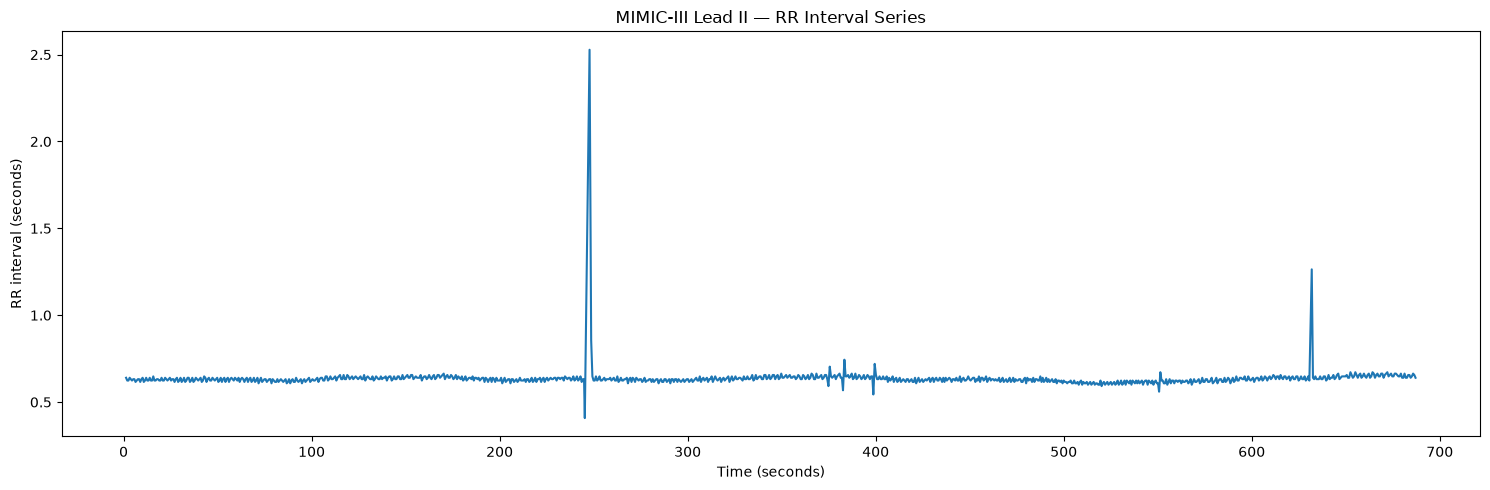

In [62]:
# ============================================================
# RR INTERVAL SERIES
# ============================================================

rr_time = r_peak_times[1:]

plt.figure(figsize=(15, 5))

plt.plot(
    rr_time,
    rr_intervals
)

plt.xlabel("Time (seconds)")
plt.ylabel("RR interval (seconds)")
plt.title("MIMIC-III Lead II — RR Interval Series")

plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# FINAL ECG → HRV FEATURE EXTRACTION
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# RR intervals already calculated
rr = np.asarray(rr_intervals, dtype=float)

# Basic artifact filtering
rr_clean = rr[
    (rr >= 0.3) &
    (rr <= 2.0)
]

# Differences between successive RR intervals
rr_diff = np.diff(rr_clean)

# HRV features
mean_rr = np.mean(rr_clean)
sdnn = np.std(rr_clean, ddof=1)
rmssd = np.sqrt(np.mean(rr_diff ** 2))
pnn50 = np.mean(np.abs(rr_diff) > 0.05) * 100

mean_hr = 60 / mean_rr

hrv_features = pd.DataFrame([{
    "record": "3609176_0003",
    "sampling_frequency": fs,
    "duration_sec": len(ecg) / fs,
    "num_r_peaks": len(r_peak_indices),
    "num_rr_intervals": len(rr),
    "num_clean_rr": len(rr_clean),
    "mean_hr": mean_hr,
    "mean_rr": mean_rr,
    "sdnn": sdnn,
    "rmssd": rmssd,
    "pnn50": pnn50
}])

print("FINAL HRV FEATURES")
display(hrv_features)

FINAL HRV FEATURES


,record,sampling_frequency,duration_sec,num_r_peaks,num_rr_intervals,num_clean_rr,mean_hr,mean_rr,sdnn,rmssd,pnn50
0,3609176_0003,125,687.304,1083,1082,1081,94.84231,0.632629,0.026338,0.036732,1.296296


In [64]:
# ============================================================
# SAVE FINAL HRV DATASET
# ============================================================

output_dir = Path("../data/processed/mimic3")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "ecg_hrv_features.csv"

hrv_features.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", hrv_features.shape)

Saved: ../data/processed/mimic3/ecg_hrv_features.csv
Shape: (1, 11)
